In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_excel("housing_data.xlsx")

df.head()

,House_ID,Location,Area_Sqft,Num_Bedrooms,Num_Bathrooms,Distance_From_City_KM,House_Age_Years,Num_Floors,Price_Lakhs
0,HSE001,Clifton,1241.0,2.0,3.0,23.2,NaN,3,75.4
1,HSE002,PECHS,3707.0,3.0,1.0,31.4,7.0,1,153.7
2,HSE003,PECHS,1809.0,1.0,1.0,30.8,30.0,2,33.0
3,HSE004,North Nazimabad,3840.0,1.0,3.0,40.0,19.0,1,137.8
4,HSE005,Malir,2337.0,5.0,3.0,21.6,33.0,2,118.5


In [3]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (135, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   House_ID               135 non-null    object 
 1   Location               135 non-null    object 
 2   Area_Sqft              124 non-null    object 
 3   Num_Bedrooms           135 non-null    object 
 4   Num_Bathrooms          124 non-null    float64
 5   Distance_From_City_KM  124 non-null    float64
 6   House_Age_Years        126 non-null    float64
 7   Num_Floors             135 non-null    int64  
 8   Price_Lakhs            135 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 9.6+ KB


,Num_Bathrooms,Distance_From_City_KM,House_Age_Years,Num_Floors,Price_Lakhs
count,124.000000,124.000000,126.000000,135.000000,135.000000
mean,1.983871,25.426613,20.119048,1.977778,850.460000
std,0.855246,44.303837,19.410351,0.777162,8597.208692
min,1.000000,-5.000000,-10.000000,1.000000,-50.000000
25%,1.000000,12.550000,9.250000,1.000000,69.650000
50%,2.000000,22.900000,20.500000,2.000000,113.200000
75%,3.000000,29.825000,28.000000,3.000000,157.050000
max,3.000000,500.000000,200.000000,3.000000,99999.000000


In [4]:
df.isnull().sum()

House_ID                  0
Location                  0
Area_Sqft                11
Num_Bedrooms              0
Num_Bathrooms            11
Distance_From_City_KM    11
House_Age_Years           9
Num_Floors                0
Price_Lakhs               0
dtype: int64

In [5]:
# CHANGE THIS if your column name is different
target_column = "Price_Lakhs"

# Separate features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

In [6]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['Num_Bathrooms', 'Distance_From_City_KM', 'House_Age_Years', 'Num_Floors']
Categorical: ['House_ID', 'Location', 'Area_Sqft', 'Num_Bedrooms']


In [7]:
# Numerical
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].mean())

# Categorical
X[categorical_features] = X[categorical_features].fillna("Missing")

In [8]:
if y.dtype == 'object':
    y = y.astype(str)
    y = LabelEncoder().fit_transform(y)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [10]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (108, 8)
Test shape: (27, 8)


In [12]:
pipeline.fit(X_train, y_train)

print("Model trained")

Model trained


In [13]:
y_pred = pipeline.predict(X_test)

print("Sample Predictions:", y_pred[:5])

Sample Predictions: [-2154.84826166   540.34935246 -7145.10164008  8784.32614446
  7505.09903722]


In [14]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("MSE:", mse)

R² Score: -12908.803079447445
MSE: 44589525.867941774


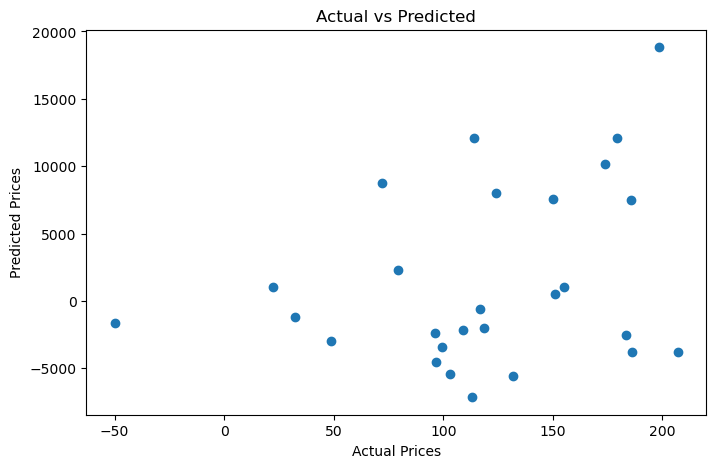

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [16]:
# Get feature names after OneHotEncoding
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = numerical_features + list(encoded_cat_features)

coefficients = pipeline.named_steps['model'].coef_

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(by="Coefficient", key=abs, ascending=False)

feature_importance.head(10)

,Feature,Coefficient
8,House_ID_HSE006,64193.409059
217,Area_Sqft_Missing,12770.243476
124,Location_Scheme 33,10824.917712
92,House_ID_HSE110,-9984.746749
173,Area_Sqft_2946.0,-9984.746749
175,Area_Sqft_3094.0,-9743.593425
84,House_ID_HSE100,-9743.593425
12,House_ID_HSE010,-9427.032156
94,House_ID_HSE114,-8913.829818
105,House_ID_HSE127,-8877.553001


In [17]:
print("""
Conclusion:
- Dataset loaded and explored
- Missing values handled
- OneHotEncoding applied to categorical features
- LabelEncoding applied to target
- Features scaled using StandardScaler
- ColumnTransformer + Pipeline used
- Model trained using Linear Regression
- Performance evaluated using R² and MSE
""")


Conclusion:
- Dataset loaded and explored
- Missing values handled
- OneHotEncoding applied to categorical features
- LabelEncoding applied to target
- Features scaled using StandardScaler
- ColumnTransformer + Pipeline used
- Model trained using Linear Regression
- Performance evaluated using R² and MSE

